In [1]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
from chephy_model_norm import truncate_sequences

# Load the Hamming and chemical distance files
with open("/home/dsi/chenbis/repos/sol_lab/majority_vote_clustering/output_files/tests/cdr3/test_ham.json", 'r') as hamming_file:
    hamming_data = json.load(hamming_file)

with open("/home/dsi/chenbis/repos/sol_lab/majority_vote_clustering/output_files/tests/cdr3/test_full.json", 'r') as chemical_file:
    chemical_data = json.load(chemical_file)

# Define thresholds for "low" chemical distance and "high" Hamming distance
low_chemical_threshold = 1
high_hamming_threshold = 1

# Collect distances for visualization
distances = []

for seq in hamming_data:
    hamming_dists = dict(hamming_data.get(seq, []))
    chemical_dists = dict(chemical_data.get(seq, []))
    
    for compared_seq, hamming_dist in hamming_dists.items():
        chemical_dist = chemical_dists.get(compared_seq, None)
        
        if chemical_dist is not None:
            distances.append({
                "hamming_distance": hamming_dist,
                "chemical_distance": chemical_dist,
                "sequence_1": seq,
                "sequence_2": compared_seq
            })

# Create a DataFrame for easier plotting
import pandas as pd
df = pd.DataFrame(distances)

In [2]:
# Add a column for the absolute difference between Hamming and chemical distances
df['abs_difference'] = abs(df['hamming_distance'] - df['chemical_distance'])

In [3]:
# Add truncated sequence columns to the dataframe
df['truncated_seq1'] = df['sequence_1'].apply(lambda x: truncate_sequences([x])[0].pop())
df['truncated_seq2'] = df['sequence_2'].apply(lambda x: truncate_sequences([x])[0].pop())

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Convenience arrays
h = df["hamming_distance"].to_numpy()
c = df["chemical_distance"].to_numpy()
ad = df["abs_difference"].to_numpy()

# For Bland–Altman
mean_dist = (h + c) / 2
diff = c - h  # signed difference


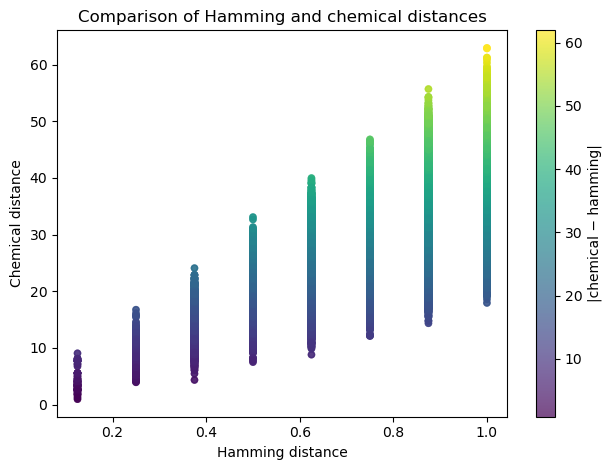

In [5]:
plt.figure()
sc = plt.scatter(h, c, c=ad, s=20, alpha=0.7)
# plt.plot([0, 1], [0, 1], linestyle="--")  # equality line for normalized distances
plt.xlabel("Hamming distance")
plt.ylabel("Chemical distance")
cbar = plt.colorbar(sc)
cbar.set_label("|chemical − hamming|")
plt.title("Comparison of Hamming and chemical distances")
plt.tight_layout()
plt.show()


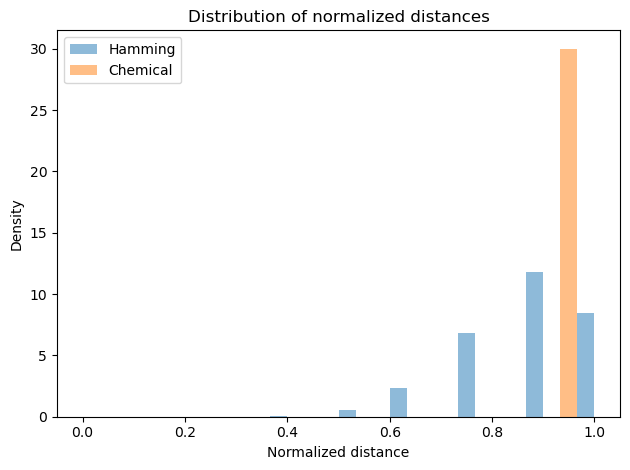

In [6]:
bins = np.linspace(0, 1, 31)  # adjust bin count if you want smoother/rougher

plt.figure()
plt.hist(h, bins=bins, density=True, alpha=0.5, label="Hamming")
plt.hist(c, bins=bins, density=True, alpha=0.5, label="Chemical")
plt.xlabel("Normalized distance")
plt.ylabel("Density")
plt.title("Distribution of normalized distances")
plt.legend()
plt.tight_layout()
plt.show()

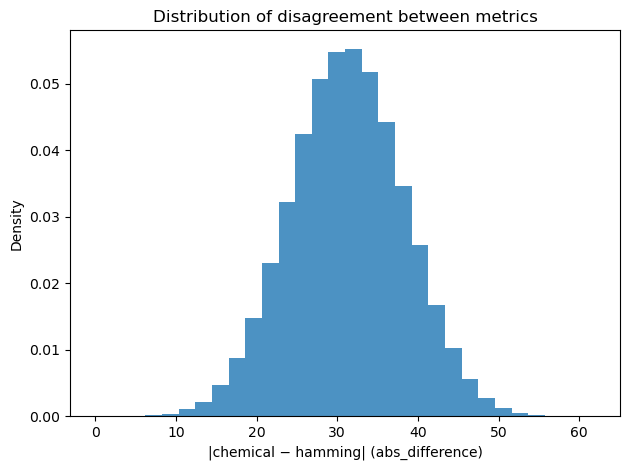

In [7]:
bins = np.linspace(0, np.nanmax(ad), 31)

plt.figure()
plt.hist(ad, bins=bins, density=True, alpha=0.8)
plt.xlabel("|chemical − hamming| (abs_difference)")
plt.ylabel("Density")
plt.title("Distribution of disagreement between metrics")
plt.tight_layout()
plt.show()


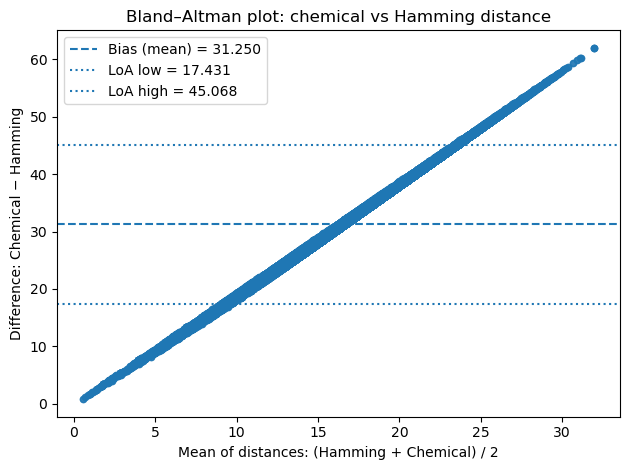

In [8]:
bias = np.nanmean(diff)
sd = np.nanstd(diff, ddof=1)
loa_low = bias - 1.96 * sd
loa_high = bias + 1.96 * sd

plt.figure()
plt.scatter(mean_dist, diff, s=20, alpha=0.7)
plt.axhline(bias, linestyle="--", label=f"Bias (mean) = {bias:.3f}")
plt.axhline(loa_low, linestyle=":", label=f"LoA low = {loa_low:.3f}")
plt.axhline(loa_high, linestyle=":", label=f"LoA high = {loa_high:.3f}")
plt.xlabel("Mean of distances: (Hamming + Chemical) / 2")
plt.ylabel("Difference: Chemical − Hamming")
plt.title("Bland–Altman plot: chemical vs Hamming distance")
plt.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_935661/3587995597.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


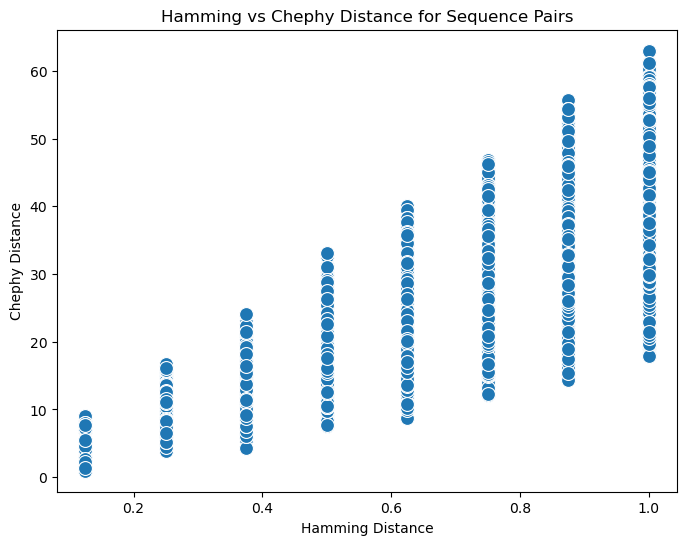

In [9]:

# Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# Create a scatter plot with seaborn
sns.scatterplot(data=df, x='hamming_distance', y='chemical_distance', s=100)

# Add labels and title
plt.xlabel('Hamming Distance')
plt.ylabel('Chephy Distance')
plt.title('Hamming vs Chephy Distance for Sequence Pairs')

# Display legend and plot
plt.legend().remove()
plt.show()


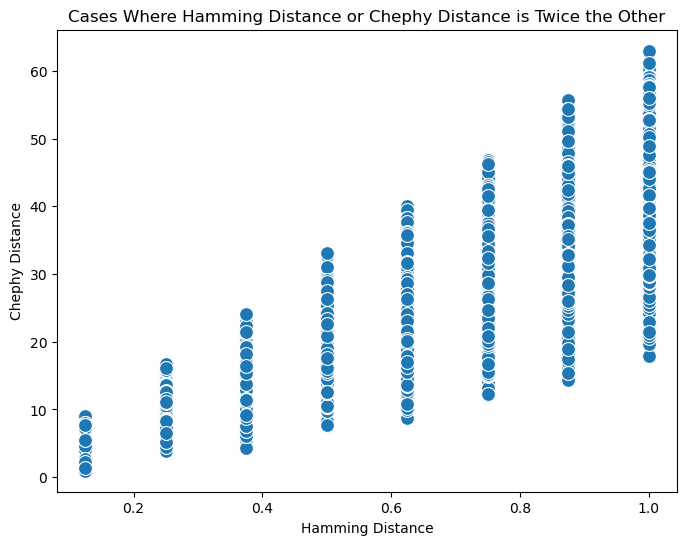

In [10]:
# Filter for cases where hamming distance is more than twice the chemical distance or vice versa
extreme_ratio_df = df[
    (df['hamming_distance'] >= 2 * df['chemical_distance']) | 
    (df['chemical_distance'] >= 2 * df['hamming_distance'])
]

# Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# Create a scatter plot with seaborn for the extreme ratio cases
sns.scatterplot(data=extreme_ratio_df, x='hamming_distance', y='chemical_distance', s=100)

# Add labels and title
plt.xlabel('Hamming Distance')
plt.ylabel('Chephy Distance')
plt.title('Cases Where Hamming Distance or Chephy Distance is Twice the Other')

# Display the plot
plt.show()


In [11]:


# Find the row with the greatest difference
greatest_diff_row = df.loc[df['abs_difference'].idxmax()]

# Display the greatest difference
print("Sequence pair with the greatest difference:")
print(greatest_diff_row)


Sequence pair with the greatest difference:
hamming_distance                1.0
chemical_distance         62.967097
sequence_1            CASSSRSSYEQYF
sequence_2           CSARGGSYNSPLHF
abs_difference            61.967097
truncated_seq1             SSSRSSYE
truncated_seq2             RGGSYNSP
Name: 31101, dtype: object


In [12]:
df2 = df.copy()
df2['seq_a'] = df2[['sequence_1', 'sequence_2']].min(axis=1)
df2['seq_b'] = df2[['sequence_1', 'sequence_2']].max(axis=1)

top_10_diff = (
    df2.sort_values('abs_difference', ascending=False)
       .drop_duplicates(subset=['seq_a', 'seq_b'], keep='first')
       .head(10)[['sequence_1', 'sequence_2', 'truncated_seq1', 'truncated_seq2',
                  'hamming_distance', 'chemical_distance', 'abs_difference']]
)

print("Top 10 sequences with the biggest difference between Hamming and Chemical distance (deduped):")
print(top_10_diff)


Top 10 sequences with the biggest difference between Hamming and Chemical distance (deduped):
                 sequence_1           sequence_2 truncated_seq1  \
575313       CSARGGSYNSPLHF        CASSSRSSYEQYF       RGGSYNSP   
456956      CASSYSGTGDYGYTF         CSGDRSSDTQYF       SYSGTGDY   
240407  CASSQTRTSGRVDPDTQYF        CASSSRSSYEQYF       TRTSGRVD   
575446       CSARGGSYNSPLHF      CASSSSGSSYNEQFF       RGGSYNSP   
231695      CASSSSGSSYNEQFF  CASSQTRTSGRVDPDTQYF       SSSGSSYN   
473665       CASMGRDINQPQHF        CASSSRSSYEQYF       MGRDINQP   
229669      CASRYRDDSYNEQFF        CASSVGGISPLHF       RYRDDSYN   
430440         CSGDRSSDTQYF        CASGDFWGDTLYF       GDRSSDTQ   
575335       CSARGGSYNSPLHF        CASSSRASYEQYF       RGGSYNSP   
575505       CSARGGSYNSPLHF       CAISDPRDSYEQYF       RGGSYNSP   

       truncated_seq2  hamming_distance  chemical_distance  abs_difference  
575313       SSSRSSYE               1.0          62.967097       61.967097  
456956       G

In [13]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA


# df = pd.read_csv("output_files/tests/cdr3/predicted clusters.csv")
# df['correct_prediction'] = (df['antigen.epitope'] == df['epitope.pred']).astype(int)

# cluster_summary = df.groupby('epitope.pred')['correct_prediction'].value_counts(normalize=True).unstack()

# for cluster_id, row in cluster_summary.iterrows():
#     plt.figure()
#     plt.pie(row, labels=['Incorrect', 'Correct'], autopct='%1.1f%%', colors=['red', 'green'])
#     plt.title(f'Correct Predictions in Cluster {cluster_id}')
#     plt.show()

In [14]:
# Load the predicted clusters data
clusters_df = pd.read_csv("/home/dsi/chenbis/repos/sol_lab/majority_vote_clustering/output_files/tests/cdr3/predicted clusters.csv")

# Merge with the distances dataframe to get epitope information
df_with_epitope = df.merge(
    clusters_df[['cdr3', 'antigen.epitope']].rename(columns={'cdr3': 'sequence_1'}),
    on='sequence_1',
    how='left'
)

# Calculate statistics per epitope
epitope_stats = df_with_epitope.groupby('antigen.epitope').agg({
    'hamming_distance': ['mean', 'std', 'median'],
    'chemical_distance': ['mean', 'std', 'median'],
    'abs_difference': ['mean', 'std', 'median']
}).round(3)

print("Distribution of Hamming and Chemical distances per epitope:")
print(epitope_stats)

# Create visualizations
epitopes = df_with_epitope['antigen.epitope'].dropna().unique()

# for epitope in epitopes:
#     epitope_data = df_with_epitope[df_with_epitope['antigen.epitope'] == epitope]
    
#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
#     # Hamming distance distribution
#     axes[0].hist(epitope_data['hamming_distance'], bins=30, alpha=0.7, color='blue', edgecolor='black')
#     axes[0].set_xlabel('Hamming Distance')
#     axes[0].set_ylabel('Frequency')
#     axes[0].set_title(f'Hamming Distance Distribution - {epitope}')
    
#     # Chemical distance distribution
#     axes[1].hist(epitope_data['chemical_distance'], bins=30, alpha=0.7, color='green', edgecolor='black')
#     axes[1].set_xlabel('Chemical Distance')
#     axes[1].set_ylabel('Frequency')
#     axes[1].set_title(f'Chemical Distance Distribution - {epitope}')
    
#     plt.tight_layout()
#     plt.show()

Distribution of Hamming and Chemical distances per epitope:
                hamming_distance               chemical_distance         \
                            mean    std median              mean    std   
antigen.epitope                                                           
AAFKRSCLK                  0.882  0.112  0.875            33.861  6.980   
AAGIGILTV                  0.812  0.127  0.875            29.831  6.905   
ADGLAYFRSSFKGG             0.876  0.099  0.875            32.607  6.146   
ADLIAYLEQATKG              0.876  0.099  0.875            32.607  6.146   
ADLIAYLKQATKG              0.870  0.107  0.875            33.441  6.344   
...                          ...    ...    ...               ...    ...   
YLGGPDFPTI                 0.957  0.075  1.000            31.587  4.352   
YLQPRTFLL                  0.911  0.114  1.000            34.558  6.734   
YPLHEQHGM                  0.888  0.114  0.875            34.158  6.449   
YQFGPDFPIA                 0.957  0.075 

In [15]:
df_with_epitope

,hamming_distance,chemical_distance,sequence_1,sequence_2,abs_difference,truncated_seq1,truncated_seq2,antigen.epitope
0,0.625,31.207235,CASSASAEFSSYEQYF,CASSSAFYGYTF,30.582235,ASAEFSSY,SSSAFYGY,RPIIRPATL
1,0.625,20.710840,CASSASAEFSSYEQYF,CASSVAGTPSYEQYF,20.085840,ASAEFSSY,SVAGTPSY,RPIIRPATL
2,0.625,21.161679,CASSASAEFSSYEQYF,CASNRGDGYTF,20.536679,ASAEFSSY,ASNRGDGY,RPIIRPATL
3,0.625,25.538857,CASSASAEFSSYEQYF,CSAVGLAGVRSYEQYF,24.913857,ASAEFSSY,GLAGVRSY,RPIIRPATL
4,0.625,23.945567,CASSASAEFSSYEQYF,CASSWGQGKSSYEQYF,23.320567,ASAEFSSY,WGQGKSSY,RPIIRPATL
...,...,...,...,...,...,...,...,...
1172792,1.000,32.348132,CASSLIYPGELFF,CASGDASGGNTLYF,31.348132,SSLIYPGE,GDASGGNT,GILGFVFTL
1172793,1.000,34.229710,CASSLIYPGELFF,CASSVEIAGRYNEQFF,33.229710,SSLIYPGE,VEIAGRYN,GILGFVFTL
1172794,1.000,34.229710,CASSLIYPGELFF,CASSVEIAGRYNEQFF,33.229710,SSLIYPGE,VEIAGRYN,GILGFVFTL
1172795,1.000,32.153615,CASSLIYPGELFF,CSARDLRLLANTGELFF,31.153615,SSLIYPGE,DLRLLANT,GILGFVFTL


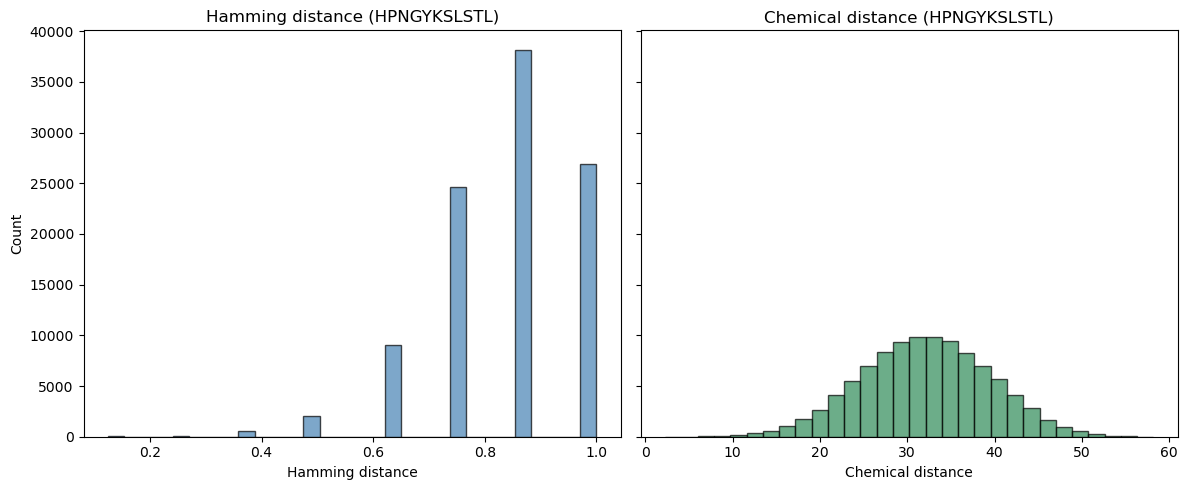

In [16]:
# Filter distances for the HPNGYKSLSTL epitope
hp_epitope = df_with_epitope[df_with_epitope['antigen.epitope'] == 'HPNGYKSLSTL']

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].hist(hp_epitope['hamming_distance'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Hamming distance (HPNGYKSLSTL)')
axes[0].set_xlabel('Hamming distance')
axes[0].set_ylabel('Count')

axes[1].hist(hp_epitope['chemical_distance'], bins=30, color='seagreen', alpha=0.7, edgecolor='black')
axes[1].set_title('Chemical distance (HPNGYKSLSTL)')
axes[1].set_xlabel('Chemical distance')

plt.tight_layout()
plt.show()

In [17]:
df_with_epitope[df_with_epitope['antigen.epitope'] == 'HPNGYKSLSTL']

,hamming_distance,chemical_distance,sequence_1,sequence_2,abs_difference,truncated_seq1,truncated_seq2,antigen.epitope
1638,0.375,13.439527,CAISESGTGFEQYF,CASSSGVGTEVFF,13.064527,SESGTGFE,SSSGVGTE,HPNGYKSLSTL
1639,0.375,17.394634,CAISESGTGFEQYF,CASSESQTGDYEQYF,17.019634,SESGTGFE,SESQTGDY,HPNGYKSLSTL
1640,0.375,10.797098,CAISESGTGFEQYF,CASSFLGTGVEQYF,10.422098,SESGTGFE,SFLGTGVE,HPNGYKSLSTL
1641,0.375,14.175044,CAISESGTGFEQYF,CASSPGTGVEQYF,13.800044,SESGTGFE,SSPGTGVE,HPNGYKSLSTL
1642,0.375,11.251024,CAISESGTGFEQYF,CASSPSGTGANEQFF,10.876024,SESGTGFE,SPSGTGAN,HPNGYKSLSTL
...,...,...,...,...,...,...,...,...
1158050,1.000,36.793116,CASSLAGAGNEQFF,CASREGDINTGELFF,35.793116,SLAGAGNE,REGDINTG,HPNGYKSLSTL
1158051,1.000,36.966311,CASSLAGAGNEQFF,CWSFAGSYYVF,35.966311,SLAGAGNE,WSFAGSYY,HPNGYKSLSTL
1158052,1.000,30.458899,CASSLAGAGNEQFF,CASSPTLVTSGNTIYF,29.458899,SLAGAGNE,PTLVTSGN,HPNGYKSLSTL
1158053,1.000,28.308538,CASSLAGAGNEQFF,CAIANRGTEAFF,27.308538,SLAGAGNE,IANRGTEA,HPNGYKSLSTL


In [18]:
len(df_with_epitope)

1172797